# Iran's Electricity Deficit — Data Analysis

Course project: forecasting Iran's power deficit and estimating what closing it would take.

Data sources (Tavanir statistical reports, SCI energy surveys and an international generation dataset) are listed in `../manual-data/PROVENANCE.md`. The scripts in `../scripts` convert the PDF/Excel sources into the CSVs used here.

**Question:** if current trends continue, how big does the deficit get, and how much capacity is needed to close it?

## Setup

In [1]:
%pip install -q pandas numpy matplotlib scipy openpyxl xlrd pymupdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"font.family": "serif", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})
SRC, RES = "../data/sources", "../results"
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

## Loading the data

Five tables come out of the parsing scripts. What a row and the columns mean in each:

| variable | one row = | columns | used for |
|---|---|---|---|
| `peak` | one year (1346–1403) | `year`, `peak_month` (month the peak fell in), `cap_grid_mw` / `cap_offgrid_mw` / `cap_total_mw` (max generating capability: national grid, off-grid, total), `supplied_max_mw` (max load actually served), `demand_max_mw` (max simultaneous demand, incl. curtailed load), `industry_at_peak_mw`, `load_factor_pct` | **the backbone**: the deficit itself (demand − supplied), the supply-break test, and both forecast trends all come from this table |
| `loss` | one year (1346–1403) | `loss_total_pct`, `loss_transmission_pct`, `loss_distribution_pct` (network losses), `thermal_efficiency_pct` (power-plant efficiency), `capacity_per_capita_w`, `generation_per_capita_kwh`, consumption shares `share_residential/industrial/other_pct`, generation-mix shares `share_nonthermal/thermal_pct` | the losses section: ~10% of the network ≈ 8 GW at the peak — the cheapest recoverable "capacity" |
| `sales` | one year (1378–1398) | electricity sold, in GWh: `residential_gwh`, `public_gwh`, `other_gwh`, `industrial_gwh`, `agriculture_gwh`, `street_lighting_gwh`, `total_gwh` | context on which sectors drive demand (industry vs households) |
| `compare` | one country-year (IRN or WLD, 1985–2025) | `entity`, `year`, `electricity_generation` (TWh), `electricity_demand` (TWh), `population` | the Iran-vs-world comparison: shows growth is not the problem, dependable peak capability is |
| `deficit` | one year where the deficit is computable (1378–1404) | `year`, `cap_total_mw`, `supplied_max_mw`, `demand_max_mw`, `deficit_mw` (= demand − supplied), `deficit_pct` (deficit as % of demand) | the main series: every deficit chart, test and forecast reads this |

All values come straight from Tavanir's own publications (and OWID for `compare`); a quick preview of each table below.

In [3]:
peak = pd.read_csv(f"{SRC}/tavanir_annual_peaks.csv")            # 58 years of annual peaks
loss = pd.read_csv(f"{SRC}/tavanir_losses_and_efficiency.csv")   # losses, efficiency, per-capita
sales = pd.read_csv(f"{SRC}/electricity_sales_by_sector.csv")    # sales by sector, 1378-1398
compare = pd.read_csv(f"{SRC}/iran_vs_world_generation.csv")     # Iran & world generation
deficit = pd.read_csv(f"{RES}/electricity_deficit_by_year.csv")  # the deficit series

for name, d in [("peak", peak), ("loss", loss), ("sales", sales),
                ("compare", compare), ("deficit", deficit)]:
    print(f"{name:8s} {d.shape[0]:3d} rows x {d.shape[1]:2d} cols")
    display(d.tail(3))

peak      58 rows x  9 cols


,year,peak_month,cap_grid_mw,cap_offgrid_mw,cap_total_mw,supplied_max_mw,demand_max_mw,industry_at_peak_mw,load_factor_pct
55,1401,مرداد,59904,197,60101,59967,"69,657.0","31,193.0",70.2
56,1402,مرداد,62497,200,62698,61220,"73,663.0","4,407.0",72.4
57,1403,تیر,64441,194,64635,62508,"80,065.0","3,690.0",72.3


loss      58 rows x 12 cols


,year,loss_total_pct,loss_transmission_pct,loss_distribution_pct,thermal_efficiency_pct,capacity_per_capita_w,generation_per_capita_kwh,share_residential_pct,share_industrial_pct,share_other_pct,share_nonthermal_pct,share_thermal_pct
55,1401,10.3,2.5,10.1,39.1,1072,4357,31.0,36.5,32.5,6.2,93.8
56,1402,10.1,2.6,9.7,39.3,1083,4523,31.0,36.6,32.4,7.7,92.3
57,1403,10.3,2.9,9.6,39.6,1101,4602,31.7,35.2,33.2,7.1,92.9


sales     21 rows x  8 cols


,year,residential_gwh,public_gwh,other_gwh,industrial_gwh,agriculture_gwh,street_lighting_gwh,total_gwh
18,1396,"83,403.0","24,328.0","18,681.0","84,145.0","39,379.0","5,017.0",254953
19,1397,"85,099.0","24,073.0","18,990.0","88,541.0","38,033.0","4,988.0",259723
20,1398,"88,500.0","25,589.0","20,143.0","97,081.0","38,764.0","5,017.0",275094


compare   82 rows x  5 cols


,entity,year,electricity_generation,electricity_demand,population
79,WLD,2023,"29,665.3","29,665.3","8,091,730,000.0"
80,WLD,2024,"30,930.2","30,930.2","8,161,970,000.0"
81,WLD,2025,"31,772.3","31,772.3","8,231,610,000.0"


deficit   36 rows x  6 cols


,year,cap_total_mw,supplied_max_mw,demand_max_mw,deficit_mw,deficit_pct
33,1402,"62,698.0",61220,73663,12443,16.9
34,1403,"64,635.0",62508,80065,17557,21.9
35,1404,NaN,62577,77498,14921,19.3


## Descriptive statistics

Summary stats first, then the shape of the deficit distribution. A skew of 2.2 (last column, `deficit_mw` row) means a long right tail: most years cluster near zero and a few recent years are far out to the right. That is also why the mean (2,612 MW) is more than three times the median (778 MW) — the histogram below makes it visible.

In [4]:
num = deficit[["demand_max_mw", "supplied_max_mw", "deficit_mw", "deficit_pct"]]
desc = num.describe().T
desc["skew"] = num.skew()
desc["kurtosis"] = num.kurtosis()
desc.round(1)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
demand_max_mw,36.0,"38,325.9","20,833.8","10,392.0","19,559.0","36,317.0","53,802.5","80,065.0",0.4,-0.9
supplied_max_mw,36.0,"35,714.1","17,558.4","9,537.0","19,073.5","34,591.5","52,538.5","62,577.0",0.1,-1.4
deficit_mw,36.0,"2,611.8","4,617.7",0.0,128.5,777.5,"1,312.5","17,557.0",2.2,3.7
deficit_pct,36.0,4.6,6.0,0.0,0.8,2.0,4.8,21.9,1.7,2.0


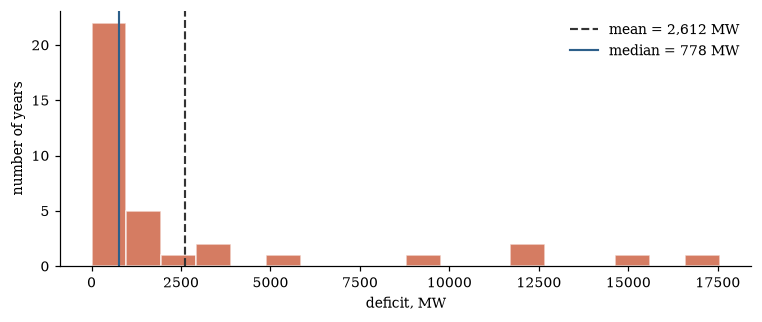

skew = 2.2  ->  long right tail: most years are small, a few recent years are extreme


In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(deficit.deficit_mw, bins=18, color="#c8502d", alpha=.75, edgecolor="white")
ax.axvline(deficit.deficit_mw.mean(), color="#333", lw=1.4, ls="--",
           label=f"mean = {deficit.deficit_mw.mean():,.0f} MW")
ax.axvline(deficit.deficit_mw.median(), color="#2d5f8a", lw=1.4,
           label=f"median = {deficit.deficit_mw.median():,.0f} MW")
ax.set_xlabel("deficit, MW"); ax.set_ylabel("number of years")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"skew = {deficit.deficit_mw.skew():.1f}  ->  long right tail: "
      f"most years are small, a few recent years are extreme")

## Outlier check (IQR rule)

Anything outside $[Q_1 - 1.5\,IQR,\ Q_3 + 1.5\,IQR]$ is suspicious. On the "industrial load at peak" column this flags exactly one point:

In [6]:
s = peak["industry_at_peak_mw"].dropna()
q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  fence [{lo:,.0f}, {hi:,.0f}]")
peak.loc[s[(s < lo) | (s > hi)].index, ["year", "industry_at_peak_mw"]]

Q1=1,118  Q3=3,114  fence [-1,878, 6,110]


,year,industry_at_peak_mw
55,1401,"31,193.0"


The 1401 value (31,193 MW) is ~10x its neighbours. Checking the source PDF, it's a typo: the real value is about 3,119 with a footnote mark "3" stuck to it. We don't use this column in the model, but it's worth reporting.

## The deficit

Definition: **deficit = max simultaneous demand - max supplied load**, i.e. demand that existed at the annual peak and was not served. Until 1398 the two lines basically overlap; from 1399 they split.

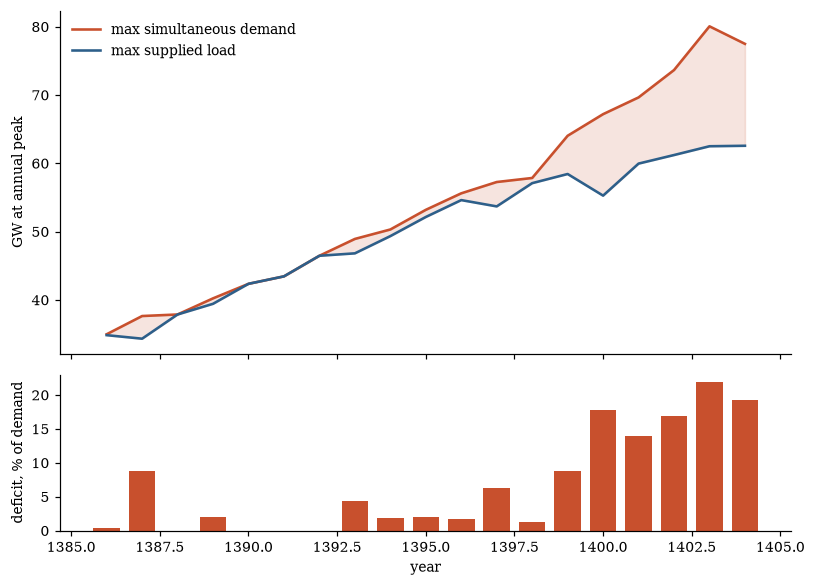

1403: 17,557 MW unserved (21.9% of demand)


In [7]:
sub = deficit[deficit.year >= 1386]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.5, 5.4), sharex=True,
                             gridspec_kw={"height_ratios": [2.2, 1]})
a1.plot(sub.year, sub.demand_max_mw/1e3, color="#c8502d", lw=1.7, label="max simultaneous demand")
a1.plot(sub.year, sub.supplied_max_mw/1e3, color="#2d5f8a", lw=1.7, label="max supplied load")
a1.fill_between(sub.year, sub.supplied_max_mw/1e3, sub.demand_max_mw/1e3,
                color="#c8502d", alpha=.15)
a1.set_ylabel("GW at annual peak"); a1.legend(frameon=False)
a2.bar(sub.year, sub.deficit_pct, color="#c8502d", width=.75)
a2.set_ylabel("deficit, % of demand"); a2.set_xlabel("year")
plt.tight_layout(); plt.show()
r = deficit[deficit.year==1403].iloc[0]
print(f"1403: {r.deficit_mw:,.0f} MW unserved ({r.deficit_pct:.1f}% of demand)")

## Network losses

Where these percentages come from: they are **not computed by us** — they are Tavanir's own
figures, read straight from the indicator table of the 58-year statistical report
(parsed by `scripts/05_parse_losses_and_efficiency.py`; the 10.32% for 1403 also matches the
official yearbook workbook to two decimals). Tavanir computes them from the annual energy
balance:

> losses % = (energy delivered into the network − energy billed to customers) / energy delivered × 100

So anything that enters the wires but never shows up on a meter counts as loss — technical
heating in lines and transformers, plus non-technical loss (unmetered connections).
Transmission and distribution losses are measured on different bases (transmission: plant to
distribution substations; distribution: substation to the meter), which is why the two lines
do not add up to the total.

The last two code lines turn the percentage into a GW figure:
`lost_gw = 1403 peak demand (80,065 MW) x 10.32/100 / 1000 ≈ 8.3 GW`.
That mixes an annual-energy percentage with a peak-power number, so it is an approximation —
but a conservative one: resistive losses grow with the square of the current, so at the peak
hour the real loss fraction is higher than the annual average, not lower.

The picture: losses fell from ~20% in the mid-1380s to ~10% now — real progress. But 10% of
an 80 GW peak is still ~8 GW, more than half of the deficit, and most of it sits in the
in-city distribution network (9.6 points) rather than the high-voltage transmission lines (2.9).

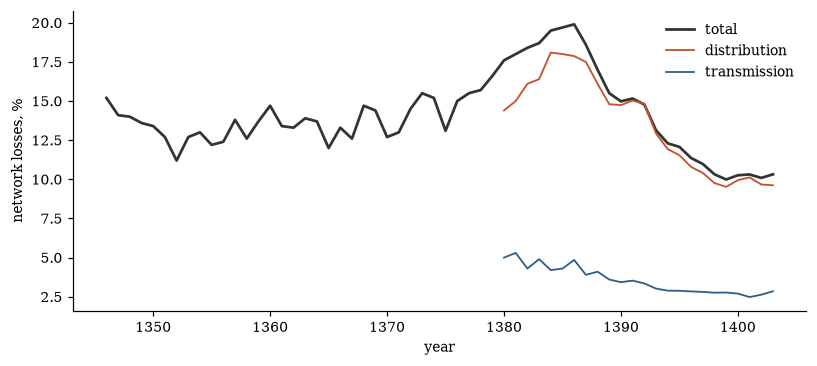

1403: total 10.32% -> about 8.3 GW at the peak


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(loss.year, loss.loss_total_pct, color="#333", lw=1.8, label="total")
ax.plot(loss.year, loss.loss_distribution_pct, color="#c8502d", lw=1.2, label="distribution")
ax.plot(loss.year, loss.loss_transmission_pct, color="#2d5f8a", lw=1.2, label="transmission")
ax.set_ylabel("network losses, %"); ax.set_xlabel("year"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
last = loss[loss.year == 1403].iloc[0]
lost_gw = deficit[deficit.year==1403].demand_max_mw.iloc[0] * last.loss_total_pct/100 / 1e3
print(f"1403: total {last.loss_total_pct}% -> about {lost_gw:.1f} GW at the peak")

## Correlations

A quick look at how the main variables move together. Each cell of the matrix is a Pearson
correlation between two variables, from -1 (perfect opposite movement, dark blue) to +1
(perfect co-movement, dark red); the diagonal is always 1 since every variable is perfectly
correlated with itself. One caution before reading it: most of these series trend upward
over 20+ years, and any two trending series come out highly correlated — so the many 0.99
cells mostly just say "everything grew together", not that one thing causes another.

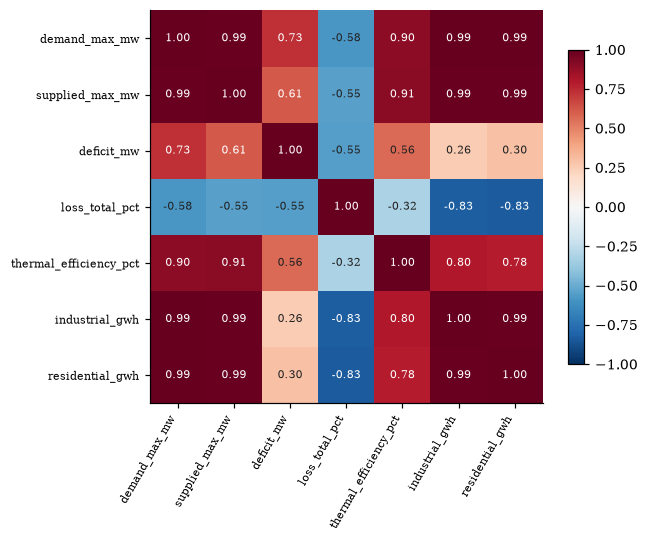

In [9]:
m = (deficit.merge(loss[["year","loss_total_pct","thermal_efficiency_pct"]], on="year")
         .merge(sales[["year","industrial_gwh","residential_gwh"]], on="year", how="left"))
cols = ["demand_max_mw","supplied_max_mw","deficit_mw","loss_total_pct",
        "thermal_efficiency_pct","industrial_gwh","residential_gwh"]
corr = m[cols].corr()
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols)), cols, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(len(cols)), cols, fontsize=7)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(corr.iloc[i,j])>.6 else "#222")
fig.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()

Two cells carry real information here:

- **deficit vs demand (0.73) is stronger than deficit vs supplied (0.61)** — the deficit
  tracks demand more closely than supply, i.e. demand kept moving along its path while
  supply stopped following. Same story the hypothesis test tells later, from another angle.
- **deficit vs losses is negative (-0.55)** — the deficit grew in exactly the years when
  network losses were at their lowest. So the deficit is not a story of a deteriorating
  grid; the grid actually improved, and the shortfall appeared anyway.

The strong negative losses-vs-consumption cells (-0.83) reflect decades of network
investment happening alongside demand growth — a shared time trend, not a causal link.
Also note the sales columns only run to 1398, so this matrix is computed on the ~21
overlapping years — a small sample, read it qualitatively.

## Iran vs the world

Iran's generation growth over the past decade is actually *above* the world average. The problem is not that nothing gets built — it is that peak demand grows ~5%/yr while dependable supply grows ~2%/yr.

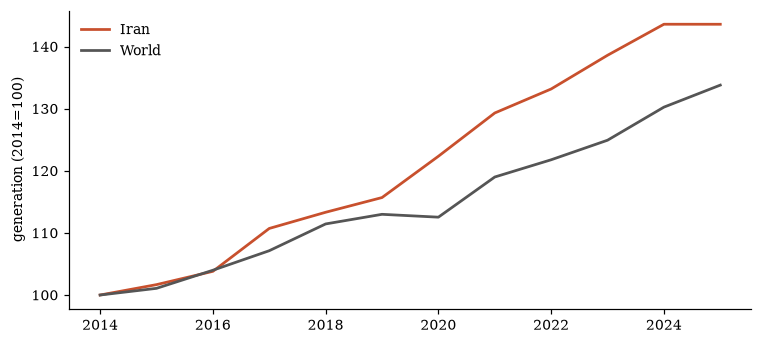

CAGR 2014-2024:  Iran 3.7%   World 2.7%


In [10]:
irn = compare[compare.entity=="IRN"].set_index("year").electricity_generation
wld = compare[compare.entity=="WLD"].set_index("year").electricity_generation
base = 2014
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(irn.loc[base:].index, 100*irn.loc[base:]/irn[base], color="#c8502d", lw=1.8, label="Iran")
ax.plot(wld.loc[base:].index, 100*wld.loc[base:]/wld[base], color="#555", lw=1.8, label="World")
ax.set_ylabel(f"generation ({base}=100)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
cagr = lambda s,a,b: 100*((s[b]/s[a])**(1/(b-a))-1)
print(f"CAGR {base}-2024:  Iran {cagr(irn,base,2024):.1f}%   World {cagr(wld,base,2024):.1f}%")

## Did demand change, or supply?

Welch's t-test on annual growth rates, before vs after 1395 (H0: same mean growth, alpha = 0.05):

In [11]:
g = deficit.sort_values("year").copy()
g["dem_growth"] = g.demand_max_mw.pct_change()*100
g["sup_growth"] = g.supplied_max_mw.pct_change()*100
pre  = g[(g.year>=1380) & (g.year<=1395)]
post = g[g.year>=1396]
pvals = {}
for col, label in [("dem_growth","demand"), ("sup_growth","supplied")]:
    a, b = pre[col].dropna(), post[col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    pvals[label] = p
    print(f"{label:9s}: {a.mean():.1f}%/yr -> {b.mean():.1f}%/yr | t={t:.2f}, p={p:.3f}")

# Holm correction: we ran two tests at once, so the smallest p is multiplied
# by 2 (then the next by 1) before comparing to alpha = 0.05
order = sorted(pvals, key=lambda k: pvals[k])
for rank, k in enumerate(order):
    adj = min(pvals[k] * (len(pvals) - rank), 1.0)
    print(f"Holm-adjusted {k:9s}: p = {adj:.3f}")

demand   : 5.9%/yr -> 4.3%/yr | t=1.03, p=0.324
supplied : 6.0%/yr -> 2.1%/yr | t=2.31, p=0.035
Holm-adjusted supplied : p = 0.071
Holm-adjusted demand   : p = 0.324


Demand growth did not change significantly; supply growth dropped from ~6%/yr to ~2%/yr. Being honest about multiple testing: since we ran two tests at once, a Holm correction doubles the smaller p-value — the supply break is then p = 0.07, significant at the 10% level but not at 5%. The conclusion does not rest on this test alone, though: the 17.6 GW deficit and the growth-rate wedge (5.2% vs 2.3%/yr) are observed facts, and the test simply asks which side moved. **The deficit is a supply-side problem.**

(Why no Diebold–Mariano test, which we would normally use to compare forecasts? DM compares the *out-of-sample errors of two competing forecast models*. Our projection horizon hasn't happened yet, and a backtest here would have ~5 annual points — far too few for the test to have any power.)

## Forecast

Log-linear trend for each series (demand on 1390-1404, supply on 1395-1404), extended to 1412, with uncertainty from resampling the residuals 4,000 times (fixed seed). This is an "if both trends continue" extrapolation, not a prediction of policy or weather.

In [12]:
def fit(col, y0, y1):
    s = deficit[(deficit.year>=y0)&(deficit.year<=y1)].dropna(subset=[col])
    b, a = np.polyfit(s.year, np.log(s[col]), 1)
    resid = np.log(s[col]) - (a + b*s.year)
    return a, b, resid.to_numpy()

a_d, b_d, r_d = fit("demand_max_mw", 1390, 1404)
a_s, b_s, r_s = fit("supplied_max_mw", 1395, 1404)
years = np.arange(1405, 1413)
rng = np.random.default_rng(14050607)
dem = np.exp(a_d + b_d*years);  sup = np.exp(a_s + b_s*years)
bt = (np.exp(a_d + b_d*years + rng.choice(r_d,(4000,len(years))))
      - np.exp(a_s + b_s*years + rng.choice(r_s,(4000,len(years)))))
fc = pd.DataFrame({"year": years, "deficit_gw": (dem-sup)/1e3,
                   "p2_5": np.percentile(bt,2.5,axis=0)/1e3,
                   "p97_5": np.percentile(bt,97.5,axis=0)/1e3})
print(f"demand trend {100*(np.exp(b_d)-1):.1f}%/yr | supply trend {100*(np.exp(b_s)-1):.1f}%/yr")
fc.round(1)

demand trend 4.7%/yr | supply trend 2.0%/yr


,year,deficit_gw,p2_5,p97_5
0,1405,19.4,14.8,23.9
1,1406,22.0,17.2,26.8
2,1407,24.8,19.8,29.8
3,1408,27.8,22.6,32.9
4,1409,30.9,25.4,36.3
5,1410,34.3,28.5,39.9
6,1411,37.8,31.8,43.0
7,1412,41.5,35.3,46.9


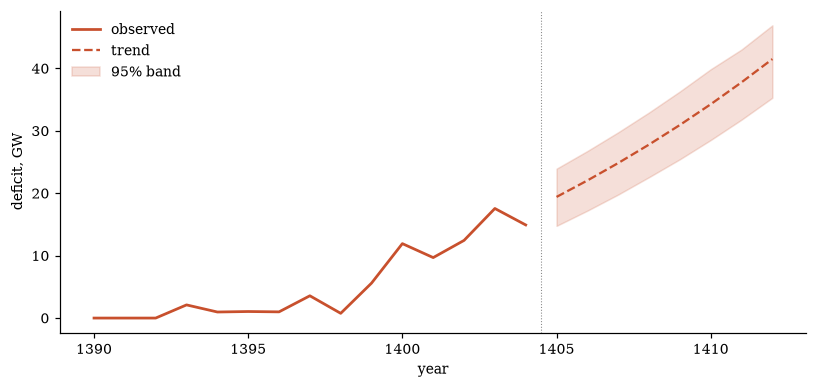

1408: 27.8 GW  [22.6 - 32.9]
1412: 41.5 GW  [35.3 - 46.9]


In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
h = deficit[deficit.year>=1390]
ax.plot(h.year, h.deficit_mw/1e3, color="#c8502d", lw=1.8, label="observed")
ax.plot(fc.year, fc.deficit_gw, color="#c8502d", lw=1.5, ls="--", label="trend")
ax.fill_between(fc.year, fc.p2_5, fc.p97_5, color="#c8502d", alpha=.18, label="95% band")
ax.axvline(1404.5, color="#888", lw=.7, ls=":")
ax.set_ylabel("deficit, GW"); ax.set_xlabel("year"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
for y in (1408, 1412):
    r = fc[fc.year==y].iloc[0]
    print(f"{y}: {r.deficit_gw:.1f} GW  [{r.p2_5:.1f} - {r.p97_5:.1f}]")

**A fair objection:** doesn't prolonged blackout kill demand itself (factories closing, people adapting), so the line can't keep rising? Partly, yes — but note (1) the projected series is *need*, not metered use: it already includes curtailed load, so idled factories *are* the deficit, and (2) refitting the demand trend only on the rationing years (1399–1404, growth 3.9%/yr vs 4.0% before) moves the 1412 gap just from 41.5 to 39.6 GW. The one warning sign is 1404, where registered demand fell 3.2% — if that is the start of demand destruction rather than a mild summer, our number is an upper bound on need, which is how it should be read.

## Conclusions

- The deficit went from ~1% of peak demand in 1398 to **22% (17.6 GW) in 1403**.
- It is a supply-side problem: demand kept its long-run path, supply growth collapsed.
- If trends continue: **~28 GW by 1408, ~41 GW by 1412**.
- Losses (~10%) are worth ~8 GW at the peak — cutting them is the cheapest "new capacity".
- Iran's total generation growth beats the world average; the problem is dependable capacity at the peak.

**Next:** the budget side — once tariff / cost-of-service figures and SATBA purchase rates are collected, gap (GW) x cost per kW gives the investment estimate.

*Limitations: "simultaneous demand" is Tavanir's own estimate and includes curtailed load; three official sources (projects under construction, official demand forecast, energy balance) need portal registration and were not available; the model is a trend, not a structural model.*